# Add NDVI to Dataset

Extracts Sentinel-2 NDVI for every field measurement point and date in the raw xlsx files,
then merges it back into the processed CSVs.

**Flow**
```
EOS-04_datasheet.xlsx  ──┐
sentinel-1.xlsx        ──┤─► stack all sheets (lat/lon/date kept)
                         │
                         ▼
             GEE: Sentinel-2 NDVI lookup
             (one API call per acquisition date, ~34 total)
                         │
                         ▼
             merge NDVI → processed CSVs
             (join on polarization + SM values)
                         │
                         ▼
             update constants.py  (add 'NDVI' to X_cols)
```

**Before running** — authenticate Google Earth Engine once:
```
earthengine authenticate
```
You need a Google account with Earth Engine access (free for research: https://earthengine.google.com/signup/).

In [1]:
import ee
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json, re

DATA_DIR = Path('..') / 'data'
CODE_DIR = Path('.')

print('DATA_DIR:', DATA_DIR.resolve())

DATA_DIR: C:\Users\am133\OneDrive\Desktop\major\.claude\worktrees\happy-ellis-de3ea5\experiments\classification_new_data\data


---
## Step 1 — Authenticate & initialise Google Earth Engine

In [2]:
import json

# ── Service Account authentication ──────────────────────────────────────────
KEY_FILE = DATA_DIR / 'ee-key.json'
GEE_PROJECT = 'sharp-weft-236811'

with open(KEY_FILE) as f:
    sa_info = json.load(f)
sa_email = sa_info['client_email']
print(f'Service account: {sa_email}')

credentials = ee.ServiceAccountCredentials(email=sa_email, key_file=str(KEY_FILE))
ee.Initialize(credentials=credentials, project=GEE_PROJECT)
print('GEE initialised successfully.')

Service account: ee-ndvi@sharp-weft-236811.iam.gserviceaccount.com


GEE initialised successfully.


---
## Step 2 — Load raw xlsx files (with lat/lon/date)

In [3]:
def parse_sheet_date(sheet_name: str) -> pd.Timestamp:
    """Parse date from sheet name like '01-06-2022', '31-07-23', '28-2-2023'."""
    s = sheet_name.strip()
    # Try DD-MM-YYYY first, then DD-MM-YY
    for fmt in ('%d-%m-%Y', '%d-%m-%y', '%d/%m/%Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    # Fallback: let pandas guess
    try:
        return pd.to_datetime(s, dayfirst=True)
    except Exception:
        return pd.NaT


def load_xlsx_with_coords(path: Path, skip_sheets=None) -> pd.DataFrame:
    """
    Stack all sheets from an xlsx file that have lat/lon columns.
    Resolves any corrupted 'Sample Date & Time' cells using the sheet name.
    Returns a DataFrame with an added 'acquisition_date' column.
    """
    skip_sheets = {s.strip() for s in (skip_sheets or [])}
    xl = pd.ExcelFile(path)
    frames = []

    for sheet in xl.sheet_names:
        sheet_clean = sheet.strip()
        if sheet_clean in skip_sheets:
            continue

        df = pd.read_excel(path, sheet_name=sheet)

        if 'Latitude (Centre of grid)' not in df.columns:
            print(f'  Skipping sheet {sheet!r} — no coordinate columns')
            continue

        # Parse acquisition date robustly
        fallback_date = parse_sheet_date(sheet_clean)
        df['acquisition_date'] = pd.to_datetime(
            df['Sample Date & Time'], errors='coerce'
        )
        # Fill any NaT (corrupted cells) with the date from the sheet name
        df['acquisition_date'] = df['acquisition_date'].fillna(fallback_date)

        if df['acquisition_date'].isna().any():
            n_bad = df['acquisition_date'].isna().sum()
            print(f'  WARNING: {n_bad} rows still have no date in sheet {sheet!r}')

        df['sheet'] = sheet_clean
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    print(f'Loaded {path.name}: {len(combined)} rows across {len(frames)} sheets')
    return combined


eos_raw = load_xlsx_with_coords(DATA_DIR / 'EOS-04_datasheet.xlsx')
sen_raw = load_xlsx_with_coords(DATA_DIR / 'sentinel-1.xlsx', skip_sheets=['UniqueCrops'])

print(f'\nEOS-04 unique dates : {eos_raw["acquisition_date"].dt.date.nunique()}')
print(f'Sentinel-1 unique dates: {sen_raw["acquisition_date"].dt.date.nunique()}')

Loaded EOS-04_datasheet.xlsx: 2900 rows across 20 sheets


C:\Users\am133\AppData\Local\Temp\ipykernel_50504\1729098263.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['acquisition_date'] = pd.to_datetime(


Loaded sentinel-1.xlsx: 2030 rows across 14 sheets

EOS-04 unique dates : 20
Sentinel-1 unique dates: 15


---
## Step 3 — Extract Sentinel-2 NDVI via GEE

One API call per acquisition date (batches all 145 points per date).  
Results are cached to `data/ndvi_cache_eos.csv` and `data/ndvi_cache_sentinel.csv`  
so the cell can be re-run safely if interrupted.

In [4]:
def get_ndvi_batch(date_str: str, lats, lons, indices, search_window: int = 10) -> dict:
    """
    Extract NDVI from the least-cloudy Sentinel-2 SR image within
    ±search_window days of date_str for all (lat, lon) points.

    Returns dict {original_index: ndvi_float_or_None}
    """
    target = ee.Date(date_str)

    lats = list(lats)
    lons = list(lons)
    indices = list(indices)

    # Build bounding box with small buffer
    bbox = ee.Geometry.BBox(
        min(lons) - 0.05, min(lats) - 0.05,
        max(lons) + 0.05, max(lats) + 0.05
    )

    # Find least-cloudy Sentinel-2 image in the time window
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(bbox)
        .filterDate(
            target.advance(-search_window, 'day'),
            target.advance(search_window + 1, 'day')
        )
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
        .sort('CLOUDY_PIXEL_PERCENTAGE')
    )

    count = s2.size().getInfo()
    if count == 0:
        print(f'    No image found for {date_str} (±{search_window} days, cloud <30%)')
        return {idx: None for idx in indices}

    image = s2.first()
    img_date  = image.date().format('YYYY-MM-dd').getInfo()
    cloud_pct = image.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'    Sentinel-2 image: {img_date}  cloud={cloud_pct:.1f}%  ({count} candidates)')

    ndvi_img = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # Build FeatureCollection
    features = [
        ee.Feature(ee.Geometry.Point([float(lon), float(lat)]), {'orig_idx': int(idx)})
        for idx, lat, lon in zip(indices, lats, lons)
    ]
    fc = ee.FeatureCollection(features)

    sampled = ndvi_img.sampleRegions(
        collection=fc,
        scale=10,
        properties=['orig_idx'],
        geometries=False
    )

    result = {idx: None for idx in indices}
    for feat in sampled.getInfo()['features']:
        result[feat['properties']['orig_idx']] = feat['properties'].get('NDVI')

    return result


def extract_ndvi_for_dataset(raw_df: pd.DataFrame, cache_path: Path,
                             lat_col='Latitude (Centre of grid)',
                             lon_col='Longitude (Centre of grid)') -> pd.Series:
    """
    Run batched NDVI extraction for every acquisition date in raw_df.
    Loads existing cache and skips already-processed dates.
    Returns a Series of NDVI values indexed like raw_df.
    """
    ndvi_series = pd.Series(index=raw_df.index, dtype=float)

    # Load existing cache
    if cache_path.exists():
        cache = pd.read_csv(cache_path, index_col=0)
        ndvi_series.update(cache['NDVI'])
        cached_indices = set(cache.index)
        print(f'Loaded cache: {len(cached_indices)} rows already processed')
    else:
        cached_indices = set()

    unique_dates = sorted(raw_df['acquisition_date'].dt.date.unique())
    print(f'Total unique dates: {len(unique_dates)}')

    for acq_date in tqdm(unique_dates, desc='Dates'):
        mask = raw_df['acquisition_date'].dt.date == acq_date
        group = raw_df[mask]

        # Skip if all rows in this date are already cached
        if set(group.index).issubset(cached_indices):
            continue

        date_str = str(acq_date)
        print(f'  {date_str}  ({len(group)} points)')

        try:
            result = get_ndvi_batch(
                date_str,
                lats=group[lat_col].values,
                lons=group[lon_col].values,
                indices=group.index.tolist()
            )
            for idx, val in result.items():
                ndvi_series[idx] = val

        except Exception as e:
            print(f'    ERROR on {date_str}: {e}')

        # Save checkpoint after every date
        ndvi_series.to_frame('NDVI').to_csv(cache_path)

    print(f'Done. Null NDVI: {ndvi_series.isna().sum()} / {len(ndvi_series)}')
    return ndvi_series


print('Functions defined. Run next cell to start extraction.')

Functions defined. Run next cell to start extraction.


In [5]:
# ── EOS-04 ──────────────────────────────────────────────────────────────────
print('=== EOS-04 NDVI extraction ===')
eos_ndvi = extract_ndvi_for_dataset(
    eos_raw,
    cache_path=DATA_DIR / 'ndvi_cache_eos.csv'
)
eos_raw['NDVI'] = eos_ndvi

print(f'\nEOS-04 NDVI stats:')
print(eos_raw['NDVI'].describe().round(4))

=== EOS-04 NDVI extraction ===
Loaded cache: 2900 rows already processed
Total unique dates: 20


Dates:   0%|          | 0/20 [00:00<?, ?it/s]

Dates: 100%|██████████| 20/20 [00:00<00:00, 578.96it/s]

Done. Null NDVI: 744 / 2900

EOS-04 NDVI stats:
count    2156.0000
mean        0.4395
std         0.2553
min         0.0616
25%         0.1862
50%         0.4118
75%         0.6808
max         0.8996
Name: NDVI, dtype: float64


In [6]:
# ── Sentinel-1 ──────────────────────────────────────────────────────────────
print('=== Sentinel-1 NDVI extraction ===')
sen_ndvi = extract_ndvi_for_dataset(
    sen_raw,
    cache_path=DATA_DIR / 'ndvi_cache_sentinel.csv'
)
sen_raw['NDVI'] = sen_ndvi

print(f'\nSentinel-1 NDVI stats:')
print(sen_raw['NDVI'].describe().round(4))

=== Sentinel-1 NDVI extraction ===
Loaded cache: 2030 rows already processed
Total unique dates: 15


Dates:   0%|          | 0/15 [00:00<?, ?it/s]

Dates: 100%|██████████| 15/15 [00:00<00:00, 713.26it/s]

Done. Null NDVI: 299 / 2030

Sentinel-1 NDVI stats:
count    1731.0000
mean        0.4783
std         0.2597
min         0.0616
25%         0.2289
50%         0.4783
75%         0.7275
max         0.8996
Name: NDVI, dtype: float64


---
## Step 4 — Merge NDVI into processed CSVs

Joins the enriched raw data back into the processed CSVs using the polarization + SM values as the merge key.  
Rows in the processed CSV that have no NDVI match (e.g. heavy cloud cover on that date) are filled with the crop-type median.

In [7]:
def merge_ndvi_into_processed(
    processed_path: Path,
    raw_enriched: pd.DataFrame,
    merge_keys: list[str],
    output_path: Path
) -> pd.DataFrame:
    """
    Merge NDVI from raw_enriched into the processed CSV.
    Merge key: exact float values of polarization + SM columns.
    Missing NDVI values are filled with the per-crop median NDVI.
    """
    proc = pd.read_csv(processed_path)
    # Drop existing NDVI column to avoid _x/_y suffix conflicts on re-run
    if 'NDVI' in proc.columns:
        proc = proc.drop(columns=['NDVI'])
    print(f'Processed rows: {len(proc)}')

    # Drop duplicate merge key rows from raw to avoid fan-out
    raw_deduped = raw_enriched[merge_keys + ['NDVI']].drop_duplicates(subset=merge_keys)

    merged = proc.merge(raw_deduped, on=merge_keys, how='left')

    n_matched  = merged['NDVI'].notna().sum()
    n_missing  = merged['NDVI'].isna().sum()
    print(f'Matched NDVI: {n_matched}  |  Missing: {n_missing}')

    if n_missing > 0:
        # Fill missing with per-crop median
        crop_median = merged.groupby('Crop Name')['NDVI'].transform('median')
        merged['NDVI'] = merged['NDVI'].fillna(crop_median)
        # Any remaining (crop has no NDVI at all) fill with global median
        merged['NDVI'] = merged['NDVI'].fillna(merged['NDVI'].median())
        print(f'Filled {n_missing} missing values with crop-type / global median')

    merged.to_csv(output_path, index=False)
    print(f'Saved → {output_path}')
    return merged


# ── EOS-04 ──────────────────────────────────────────────────────────────────
print('=== EOS-04 ===')
eos_final = merge_ndvi_into_processed(
    processed_path=DATA_DIR / 'eos-04-processed.csv',
    raw_enriched=eos_raw,
    merge_keys=['HH-pol', 'HV-pol', 'SM1 (%)'],
    output_path=DATA_DIR / 'eos-04-processed.csv'
)
print(eos_final[['HH-pol', 'HV-pol', 'SM1 (%)', 'Crop Name', 'NDVI']].head(5).to_string())

print()

# ── Sentinel-1 ──────────────────────────────────────────────────────────────
print('=== Sentinel-1 ===')
sen_final = merge_ndvi_into_processed(
    processed_path=DATA_DIR / 'sentinel-1-processed.csv',
    raw_enriched=sen_raw,
    merge_keys=['VH-pol', 'VV-pol', 'SM1 (%)'],
    output_path=DATA_DIR / 'sentinel-1-processed.csv'
)
print(sen_final[['VH-pol', 'VV-pol', 'SM1 (%)', 'Crop Name', 'NDVI']].head(5).to_string())

=== EOS-04 ===
Processed rows: 2528
Matched NDVI: 1953  |  Missing: 575
Filled 575 missing values with crop-type / global median
Saved → ..\data\eos-04-processed.csv
    HH-pol    HV-pol  SM1 (%)    Crop Name      NDVI
0 -9.30941 -17.00176      8.2       Fallow  0.187340
1 -8.10325 -15.88235     44.8  Perl Millet  0.631529
2 -9.62345 -17.15174      6.0       Fallow  0.147122
3 -9.94934 -19.37645      5.7        Ortho  0.175938
4 -6.80651 -17.59076      2.7       Fallow  0.151157

=== Sentinel-1 ===


Processed rows: 1816
Matched NDVI: 1531  |  Missing: 285
Filled 285 missing values with crop-type / global median
Saved → ..\data\sentinel-1-processed.csv
    VH-pol    VV-pol  SM1 (%)     Crop Name      NDVI
0 -19.3557 -13.54610      4.6        Fallow  0.107719
1 -17.1605 -10.46910      7.2  Pearl Millet  0.089744
2 -17.8729  -9.98927      6.4        Fallow  0.094618
3 -17.7906 -11.93460      9.6         Lemon  0.188643
4 -17.3646 -10.73270      3.9        Fallow  0.181406


---
## Step 5 — Update `constants.py`

Adds `'NDVI'` to `X_cols_eos` and `X_cols_sentinel` so all experiment classes pick it up automatically.

In [8]:
constants_path = CODE_DIR / 'constants.py'
text = constants_path.read_text(encoding='utf-8')

# Only update if NDVI not already present
if 'NDVI' in text:
    print('constants.py already contains NDVI — no changes needed.')
else:
    text = text.replace(
        "X_cols_eos = ['HH-pol', 'HV-pol']",
        "X_cols_eos = ['HH-pol', 'HV-pol', 'NDVI']"
    )
    text = text.replace(
        "X_cols_sentinel = ['VH-pol', 'VV-pol']",
        "X_cols_sentinel = ['VH-pol', 'VV-pol', 'NDVI']"
    )
    constants_path.write_text(text, encoding='utf-8')
    print('constants.py updated:')

print()
print(constants_path.read_text(encoding='utf-8'))

constants.py already contains NDVI — no changes needed.

from pathlib import Path

_EXPERIMENT_ROOT = Path(__file__).resolve().parent.parent

DATA_PATH = _EXPERIMENT_ROOT / 'data'
OUTPUT_PATH = _EXPERIMENT_ROOT / 'output'

SENTINEL_FILE = 'sentinel-1-processed.csv'
EOS_FILE = 'eos-04-processed.csv'

X_cols_eos = ['HH-pol', 'HV-pol', 'NDVI']
X_cols_sentinel = ['VH-pol', 'VV-pol', 'NDVI']

y_col = ['SM1 (%)']


---
## Step 6 — Verify

Quick sanity check that NDVI is present, in a realistic range, and varies by crop.


=== EOS-04 ===
NDVI range : 0.062 → 0.900
NDVI nulls : 0
NDVI by crop:
                     mean    std  count
Crop Name                              
Bhaji               0.666  0.167      4
Chickori            0.631  0.179     60
Daicha              0.310    NaN      1
Dalia               0.727    NaN      1
Datura              0.480    NaN      1
Fallow              0.217  0.134   1004
Fallow&Grass        0.480  0.000      4
Fodder              0.613  0.157     19
Fodder&Jowar        0.480    NaN      1
Grass               0.658  0.212      6
Green Manary        0.480  0.000      2
Jowar               0.406  0.123     24
Kshan               0.480  0.000      2
Lemon               0.341  0.110     16
Maize               0.166  0.061      5
Mustard             0.563  0.145     10
Orchad              0.455  0.000      3
Ortho               0.176    NaN      1
Paddy               0.708  0.136    602
Perl Millet         0.473  0.196    163
Sorgham             0.825  0.030      5
Sorgham&

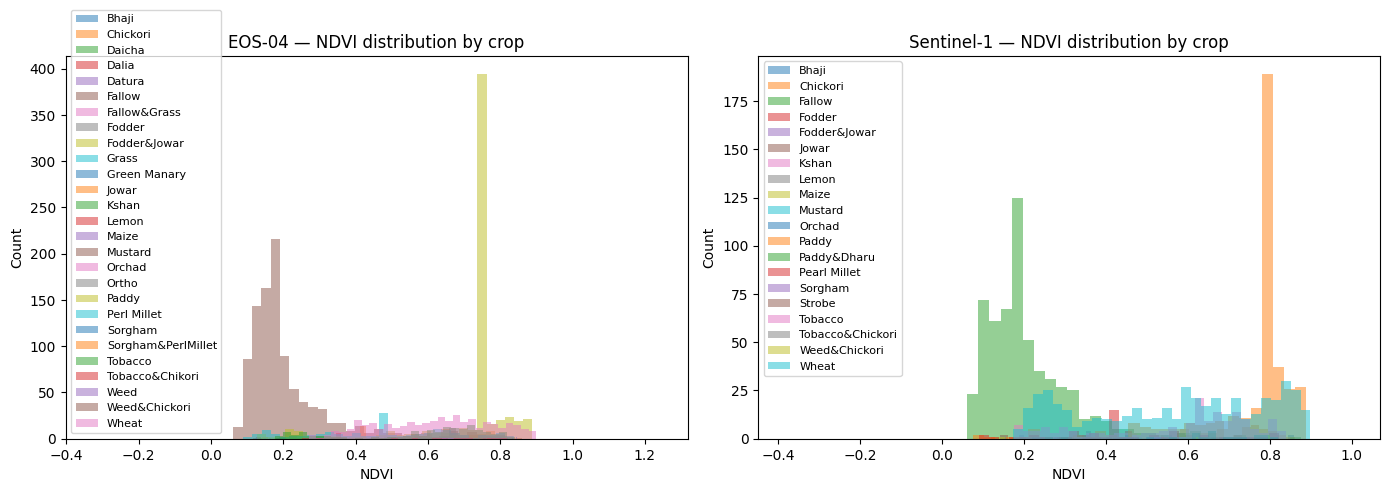


All done. Re-run run_all.ipynb to train models with NDVI as an additional feature.


In [9]:
import matplotlib.pyplot as plt

for label, df in [('EOS-04', eos_final), ('Sentinel-1', sen_final)]:
    print(f'\n=== {label} ===')
    print(f'NDVI range : {df["NDVI"].min():.3f} → {df["NDVI"].max():.3f}')
    print(f'NDVI nulls : {df["NDVI"].isna().sum()}')
    print('NDVI by crop:')
    print(df.groupby('Crop Name')['NDVI'].agg(['mean','std','count']).round(3).to_string())

# Plot NDVI distribution per crop for EOS-04
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, df) in zip(axes, [('EOS-04', eos_final), ('Sentinel-1', sen_final)]):
    for crop, grp in df.groupby('Crop Name'):
        ax.hist(grp['NDVI'].dropna(), bins=30, alpha=0.5, label=crop)
    ax.set_title(f'{label} — NDVI distribution by crop')
    ax.set_xlabel('NDVI')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR.parent / 'output' / 'ndvi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll done. Re-run run_all.ipynb to train models with NDVI as an additional feature.')

---
## Step 7 — Write NDVI back into the original xlsx files

Adds `NDVI` as the last column in every data sheet of `EOS-04_datasheet.xlsx` and `sentinel-1.xlsx`.  
Each row is matched by sheet (date) and row order — no separate files created.

In [10]:
from openpyxl.utils import get_column_letter

def autofit_columns(worksheet):
    """Set each column width to fit its widest cell value."""
    for col in worksheet.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                max_len = max(max_len, len(str(cell.value) if cell.value is not None else ''))
            except Exception:
                pass
        worksheet.column_dimensions[col_letter].width = min(max_len + 2, 50)


def write_ndvi_to_xlsx(
    source_path: Path,
    enriched_df: pd.DataFrame,
    skip_sheets=None,
):
    """
    Overwrites source_path in-place, adding NDVI as the last column.
    Each row matched by (Latitude, Longitude) within its date sheet.
    Column widths are auto-fitted so no ### display issue in Excel.
    """
    skip_sheets = {s.strip() for s in (skip_sheets or [])}

    # Read all sheets into memory first — releases file lock on Windows
    with pd.ExcelFile(source_path) as xl:
        sheet_names = xl.sheet_names
        sheets = {s: pd.read_excel(xl, sheet_name=s) for s in sheet_names}

    tmp_path = source_path.with_suffix('.tmp.xlsx')

    with pd.ExcelWriter(tmp_path, engine='openpyxl') as writer:
        for sheet in sheet_names:
            sheet_clean = sheet.strip()
            orig = sheets[sheet].copy()

            if sheet_clean in skip_sheets or 'Latitude (Centre of grid)' not in orig.columns:
                orig.to_excel(writer, sheet_name=sheet, index=False)
                autofit_columns(writer.sheets[sheet])
                print(f'  {sheet!r:30s}  copied unchanged')
                continue

            if 'NDVI' in orig.columns:
                orig = orig.drop(columns=['NDVI'])

            sheet_rows = enriched_df[enriched_df['sheet'] == sheet_clean][
                ['Latitude (Centre of grid)', 'Longitude (Centre of grid)', 'NDVI']
            ].copy()

            orig['_lat_r'] = orig['Latitude (Centre of grid)'].round(6)
            orig['_lon_r'] = orig['Longitude (Centre of grid)'].round(6)
            sheet_rows = sheet_rows.copy()
            sheet_rows['_lat_r'] = sheet_rows['Latitude (Centre of grid)'].round(6)
            sheet_rows['_lon_r'] = sheet_rows['Longitude (Centre of grid)'].round(6)

            merged = orig.merge(
                sheet_rows[['_lat_r', '_lon_r', 'NDVI']].drop_duplicates(['_lat_r', '_lon_r']),
                on=['_lat_r', '_lon_r'],
                how='left'
            ).drop(columns=['_lat_r', '_lon_r'])

            merged.to_excel(writer, sheet_name=sheet, index=False)
            autofit_columns(writer.sheets[sheet])

            n_filled = merged['NDVI'].notna().sum()
            n_null   = merged['NDVI'].isna().sum()
            print(f'  {sheet!r:30s}  matched={n_filled}  no-cloud-free-image={n_null}')

    tmp_path.replace(source_path)
    print(f'\nOverwrote → {source_path}')


eos_lookup = eos_raw[['sheet', 'Latitude (Centre of grid)', 'Longitude (Centre of grid)', 'NDVI', 'acquisition_date']].copy()
sen_lookup = sen_raw[['sheet', 'Latitude (Centre of grid)', 'Longitude (Centre of grid)', 'NDVI', 'acquisition_date']].copy()

# ── EOS-04 ──────────────────────────────────────────────────────────────────
print('=== EOS-04_datasheet.xlsx ===')
write_ndvi_to_xlsx(
    source_path = DATA_DIR / 'EOS-04_datasheet.xlsx',
    enriched_df = eos_lookup,
)

print()

# ── Sentinel-1 ──────────────────────────────────────────────────────────────
print('=== sentinel-1.xlsx ===')
write_ndvi_to_xlsx(
    source_path = DATA_DIR / 'sentinel-1.xlsx',
    enriched_df = sen_lookup,
    skip_sheets = ['UniqueCrops'],
)

for fname in ['EOS-04_datasheet_with_ndvi.xlsx', 'sentinel-1_with_ndvi.xlsx']:
    p = DATA_DIR / fname
    if p.exists():
        p.unlink()
        print(f'Deleted {fname}')


=== EOS-04_datasheet.xlsx ===


  '01-06-2022'                    matched=143  no-cloud-free-image=2
  '18-06-2022'                    matched=144  no-cloud-free-image=1
  '22-07-2022'                    matched=0  no-cloud-free-image=145
  '08-08-2022'                    matched=0  no-cloud-free-image=145
  '25-08-2022'                    matched=0  no-cloud-free-image=145
  '11-09-2022'                    matched=143  no-cloud-free-image=2
  '28-09-2022'                    matched=145  no-cloud-free-image=0
  '15-10-2022'                    matched=145  no-cloud-free-image=0
  '18-11-2022 '                   matched=143  no-cloud-free-image=2
  '22-12-2022'                    matched=145  no-cloud-free-image=0
  '08-01-2023'                    matched=143  no-cloud-free-image=2
  '25-01-2023'                    matched=145  no-cloud-free-image=0
  '11-02-2023 '                   matched=145  no-cloud-free-image=0
  '28-2-2023'                     matched=143  no-cloud-free-image=2
  '20-04-2023'                    


Overwrote → ..\data\EOS-04_datasheet.xlsx

=== sentinel-1.xlsx ===
  '16-06-2022'                    matched=144  no-cloud-free-image=1
  '28-06-2022'                    matched=145  no-cloud-free-image=0
  '22-07-2022'                    matched=0  no-cloud-free-image=145
  '27-08-2022'                    matched=0  no-cloud-free-image=145
  '08-09-2022'                    matched=143  no-cloud-free-image=2
  '20-09-2022'                    matched=145  no-cloud-free-image=0


  '14-10-2022'                    matched=145  no-cloud-free-image=0
  '19-11-2022 '                   matched=143  no-cloud-free-image=2
  '13-12-2022'                    matched=145  no-cloud-free-image=0
  '18-01-2023'                    matched=145  no-cloud-free-image=0
  '30-01-2023'                    matched=145  no-cloud-free-image=0
  '11-02-2023 '                   matched=145  no-cloud-free-image=0
  '07-03-2023'                    matched=143  no-cloud-free-image=2
  '19-03-2023'                    matched=143  no-cloud-free-image=2
  'UniqueCrops'                   copied unchanged



Overwrote → ..\data\sentinel-1.xlsx
